In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('tovar_moving.csv', parse_dates=['date'])
df.rename(columns={'quantity(qty)': 'qty'}, inplace=True)
df.set_index('date', inplace=True)
df.index.freq = 'D'  # Явно указываем, что данные дневные (убирает Warning)

test_val = df.iloc[-1]['qty']
df_train = df.iloc[:-1]

print("Задание 1:")
print("Последнее значение отложено в test. Фактическое значение:", test_val)
print("Размер обучающей выборки:", len(df_train))

Задание 1:
Последнее значение отложено в test. Фактическое значение: 423846.0
Размер обучающей выборки: 1438


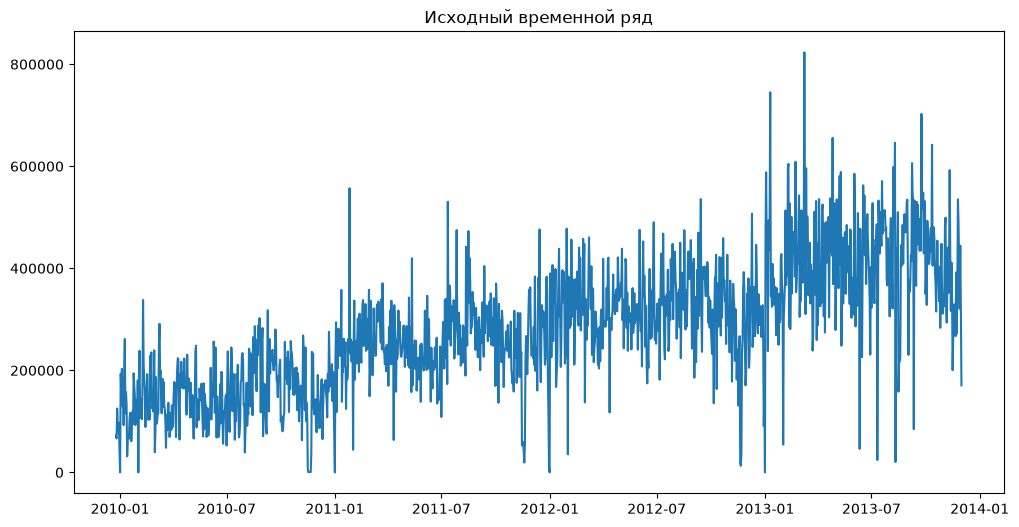

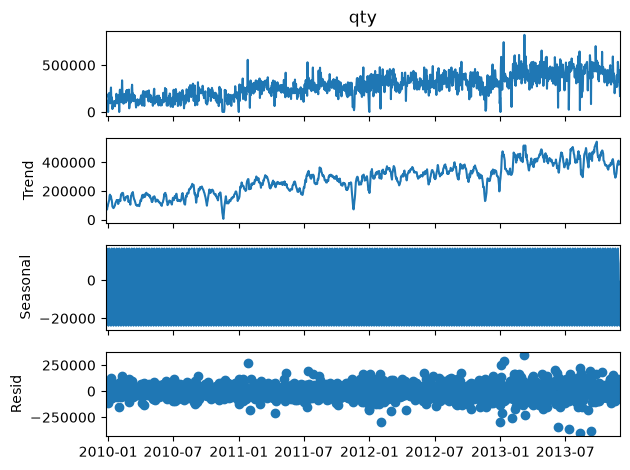

Задание 2:
Визуализация и декомпозиция ряда выполнены выше.


In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df_train.index, df_train['qty'])
plt.title('Исходный временной ряд')
plt.show()

decomposition = seasonal_decompose(df_train['qty'], period=7)
fig = decomposition.plot()
plt.show()

print("Задание 2:")
print("Визуализация и декомпозиция ряда выполнены выше.")

In [6]:
model_es = SimpleExpSmoothing(df_train['qty']).fit(smoothing_level=0.7, optimized=False)
forecast_es = model_es.forecast(1).iloc[0]  # Исправлено здесь

print("Задание 3:")
print("Прогноз (экспоненциальное сглаживание, alpha=0.7):", round(forecast_es, 2))
print("Фактическое значение:", test_val)
print("Абсолютная ошибка:", round(abs(forecast_es - test_val), 2))

Задание 3:
Прогноз (экспоненциальное сглаживание, alpha=0.7): 225015.52
Фактическое значение: 423846.0
Абсолютная ошибка: 198830.48


Задание 4:
Проверка исходного ряда на стационарность:


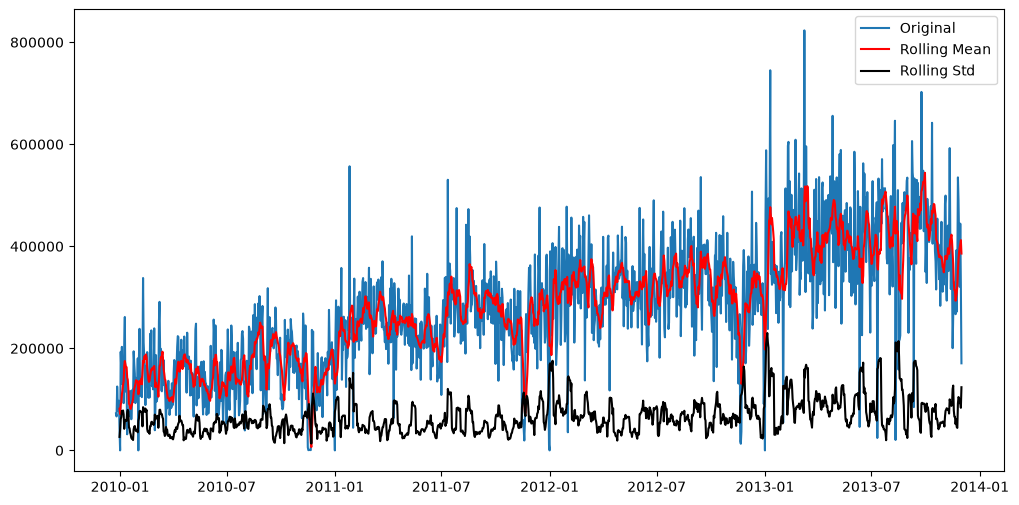

Результат теста Дики-Фуллера:
Статистика: -2.255302641033795
p-value: 0.18678903123416635
Критические значения: {'1%': np.float64(-3.434973278556316), '5%': np.float64(-2.8635818545830376), '10%': np.float64(-2.567857072940785)}

Проверка ряда после взятия разности первого порядка (d=1):


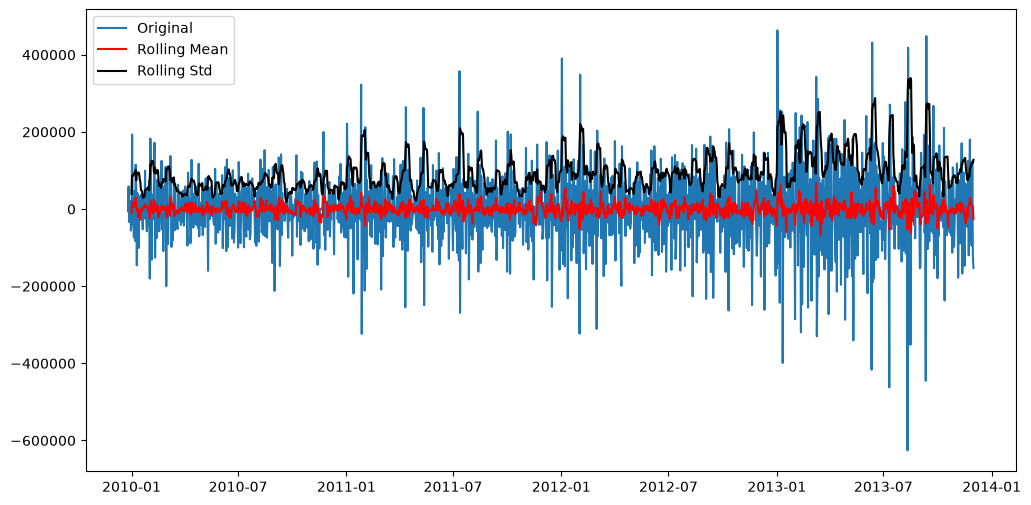

Результат теста Дики-Фуллера:
Статистика: -13.780727380503894
p-value: 9.307227521335782e-26
Критические значения: {'1%': np.float64(-3.434973278556316), '5%': np.float64(-2.8635818545830376), '10%': np.float64(-2.567857072940785)}


In [11]:
def test_stationarity(timeseries):
    plt.figure(figsize=(12, 6))
    plt.plot(timeseries, label='Original')
    plt.plot(timeseries.rolling(window=7).mean(), label='Rolling Mean', color='red')
    plt.plot(timeseries.rolling(window=7).std(), label='Rolling Std', color='black')
    plt.legend()
    plt.show()
    
    adftest = adfuller(timeseries, autolag='AIC')
    print('Результат теста Дики-Фуллера:')
    print(f'Статистика: {adftest[0]}')
    print(f'p-value: {adftest[1]}')
    print(f'Критические значения: {adftest[4]}')

print("Задание 4:")
print("Проверка исходного ряда на стационарность:")
test_stationarity(df_train['qty'])

df_diff = df_train['qty'].diff().dropna()
print("\nПроверка ряда после взятия разности первого порядка (d=1):")
test_stationarity(df_diff)

<Figure size 1400x400 with 0 Axes>

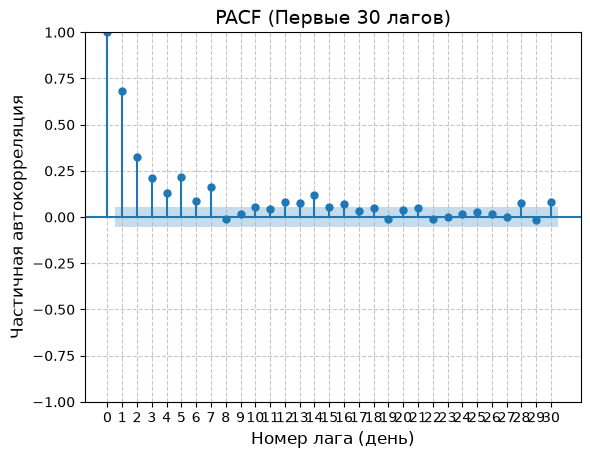

In [15]:
plt.figure(figsize=(14, 4)) # Делаем график шире и ниже
plot_pacf(df_train['qty'], lags=30, alpha=0.05) # Строго 30 лагов
plt.title('PACF (Первые 30 лагов)', fontsize=14)
plt.xlabel('Номер лага (день)', fontsize=12)
plt.ylabel('Частичная автокорреляция', fontsize=12)
plt.xticks(range(0, 31)) # Подписываем каждый лаг
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [18]:
p = 7

print("Задание 6:")
print(f"Построение модели AR с порядком p={p} на исходном временном ряду...")
model_ar = AutoReg(df_train['qty'], lags=p).fit()
forecast_ar = model_ar.forecast(1).iloc[0]
print("Прогноз (Модель AR):", round(forecast_ar, 2))

Задание 6:
Построение модели AR с порядком p=7 на исходном временном ряду...
Прогноз (Модель AR): 345269.61


In [19]:
print("Задание 7:")
print("--- Сравнение результатов ---")
print(f"Фактическое значение (test): {test_val}")
print(f"Прогноз (Экспоненциальное сглаживание): {round(forecast_es, 2)}")
print(f"Прогноз (Модель AR): {round(forecast_ar, 2)}")

Задание 7:
--- Сравнение результатов ---
Фактическое значение (test): 423846.0
Прогноз (Экспоненциальное сглаживание): 225015.52
Прогноз (Модель AR): 345269.61
